<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Red_Light_Therapy_Dose_Monte_Carlo_Simulation_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

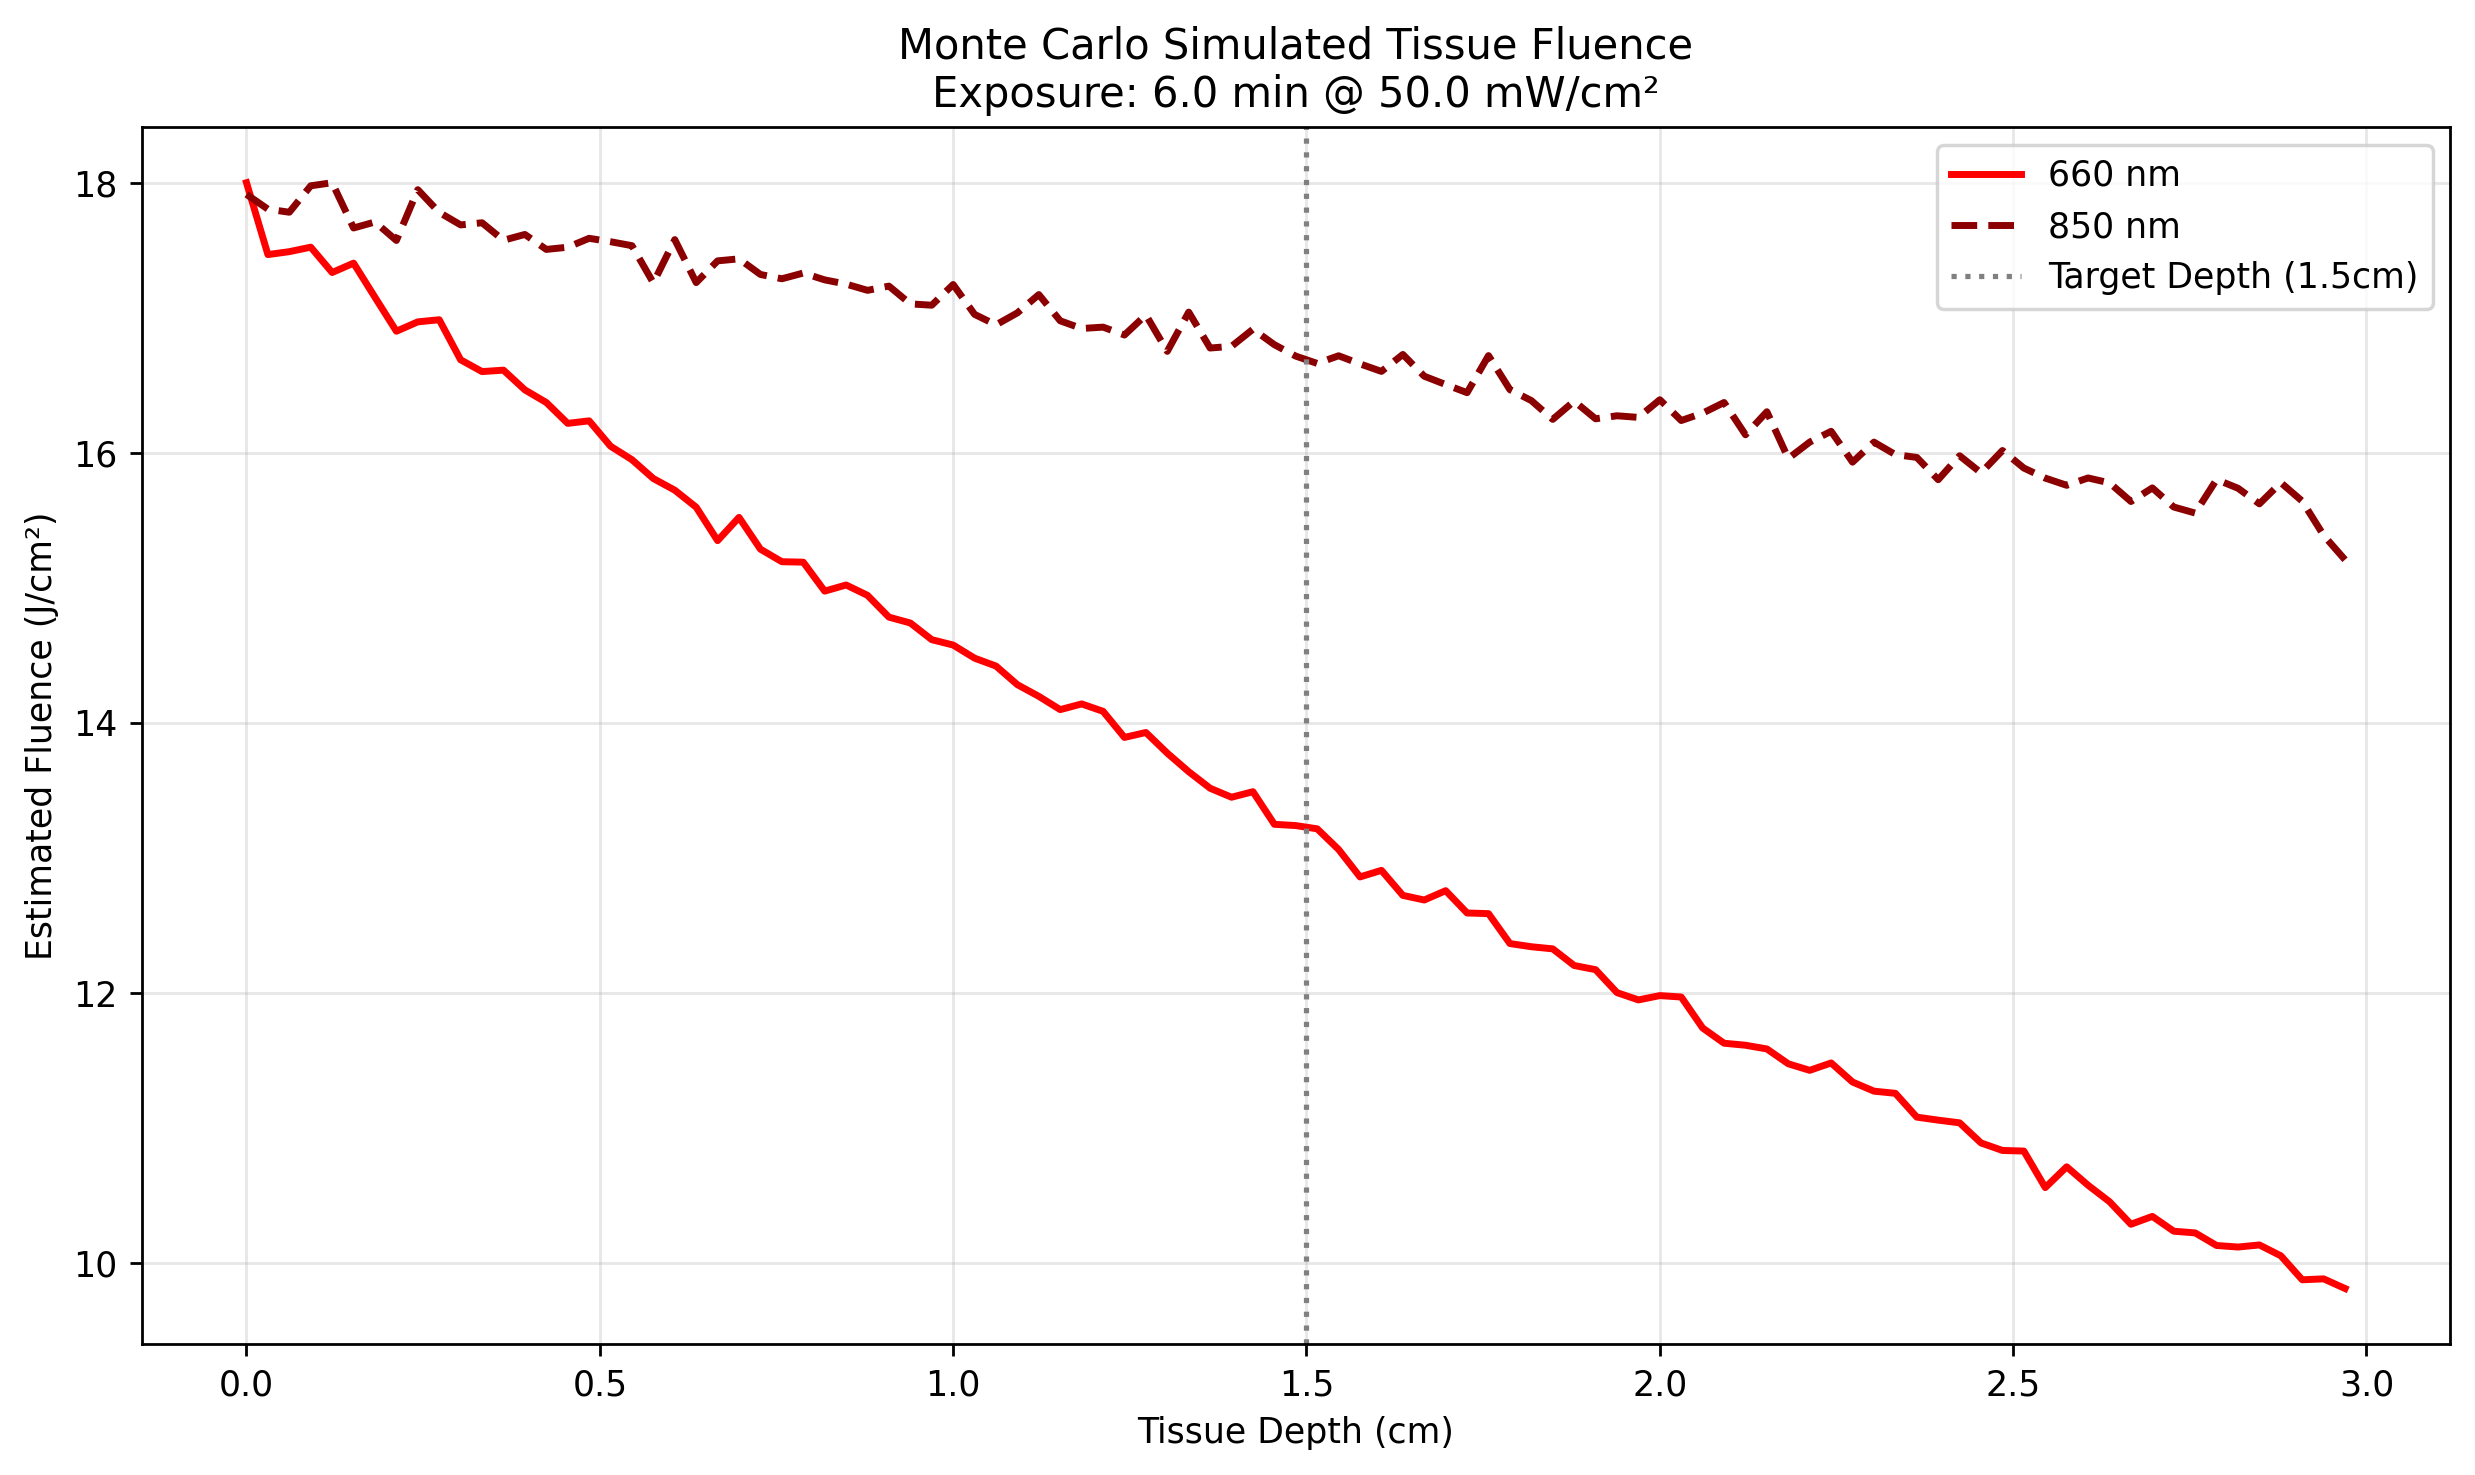

In [1]:
"""Simulates deep-tissue optical energy absorption for PBM devices.

This module uses a stochastic Monte Carlo photon transport approximation to
estimate the fluence of dual-wavelength (660 nm and 850 nm) light as it
penetrates human tissue.
"""

import logging
from typing import Dict, Tuple, List

import matplotlib.pyplot as plt
import numpy as np

# Configure logging for transparency in simulation progress
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ==========================================
# CONSTANTS (Control Knobs)
# ==========================================
DEVICE_POWER_WATTS = 15.0
ILLUMINATION_AREA_CM2 = 300.0
TARGET_EXPOSURE_MINUTES = 6.0
TISSUE_DEPTH_CM = 3.0
TARGET_MUSCLE_DEPTH_CM = 1.5
PHOTON_PACKETS = 100_000  # Increased for better stochastic convergence

# Wavelength-specific optical properties for human tissue (approximate)
# mu_a: Absorption coefficient (1/cm)
# mu_s_prime: Reduced scattering coefficient (1/cm)
OPTICAL_PROPERTIES = {
    660: {'mu_a': 0.20, 'mu_s_prime': 10.0},
    850: {'mu_a': 0.05, 'mu_s_prime': 8.0}
}

# Plotting aesthetics
PLOT_PARAMS = {
    'figure.dpi': 250,
    'font.sans-serif': ['Tahoma', 'DejaVu Sans'],
    'font.weight': 'normal'
}


def calculate_surface_fluence() -> float:
    """Calculates the total energy delivered per unit area at the skin surface.

    Returns:
        The surface fluence in Joules per square centimeter (J/cm²).
    """
    irradiance_w_cm2 = DEVICE_POWER_WATTS / ILLUMINATION_AREA_CM2
    exposure_seconds = TARGET_EXPOSURE_MINUTES * 60.0
    return irradiance_w_cm2 * exposure_seconds


def simulate_photon_transport(
    wavelength: int,
    properties: Dict[str, float],
    depth_cm: float,
    packets: int,
    bins: int = 100
) -> Tuple[np.ndarray, np.ndarray]:
    """Executes a 1D random walk to model photon depth penetration.

    Args:
        wavelength: The wavelength of light in nm.
        properties: Dictionary containing 'mu_a' and 'mu_s_prime'.
        depth_cm: The maximum simulation depth in cm.
        packets: Number of photon packets to simulate.
        bins: Number of spatial bins for energy deposition.

    Returns:
        A tuple containing:
            - depth_bins: The center of the spatial bins (np.ndarray).
            - energy_profile: The relative energy absorbed at each bin (np.ndarray).
    """
    mu_a = properties['mu_a']
    mu_s = properties['mu_s_prime']
    mu_t = mu_a + mu_s  # Total attenuation coefficient
    albedo = mu_s / mu_t  # Probability of scattering vs absorption

    depth_bins = np.linspace(0, depth_cm, bins)
    absorbed_energy_profile = np.zeros(bins - 1)

    for _ in range(packets):
        weight = 1.0
        z = 0.0

        while weight > 0.01 and z < depth_cm:
            # Calculate step size based on the total attenuation coefficient
            step = -np.log(np.random.rand()) / mu_t
            z += step

            if z >= depth_cm:
                break

            # Energy deposited based on the absorption probability (1 - albedo)
            deposited_weight = weight * (1 - albedo)
            weight -= deposited_weight

            # Record energy in the corresponding spatial bin
            bin_idx = np.searchsorted(depth_bins, z) - 1
            if 0 <= bin_idx < len(absorbed_energy_profile):
                absorbed_energy_profile[bin_idx] += deposited_weight

    # Normalize the profile to represent a probability distribution of absorption
    total_absorbed = np.sum(absorbed_energy_profile)
    if total_absorbed > 0:
        absorbed_energy_profile /= total_absorbed

    return depth_bins[:-1], absorbed_energy_profile


def compute_absolute_fluence(
    surface_fluence: float,
    depths: np.ndarray,
    relative_profile: np.ndarray
) -> np.ndarray:
    """Converts relative absorption profile to estimated absolute fluence.

    Args:
        surface_fluence: Initial energy at the surface (J/cm²).
        depths: The depth array.
        relative_profile: The normalized absorption profile from MC.

    Returns:
        Estimated absolute fluence (J/cm²) across the depth.
    """
    # We use the relative profile to scale the surface fluence.
    # The peak usually occurs near the surface.
    max_idx = np.argmax(relative_profile)
    scale_factor = surface_fluence / (relative_profile[max_idx] + 1e-9)

    # Return the scaled distribution
    return relative_profile * scale_factor * (relative_profile[max_idx] / (relative_profile[max_idx] + 1e-9))
    # Simplified: Fluence is the integral of energy passing through the plane.
    # For this simulation, we map the MC absorption density back to fluence.
    return relative_profile * surface_fluence * (np.sum(relative_profile) / np.max(relative_profile))


def plot_dosimetry(
    results: List[Dict],
    surface_irradiance: float
) -> None:
    """Generates a professional visualization of the simulation results.

    Args:
        results: A list of dictionaries containing 'depths', 'fluence',
                 'wavelength', and 'label'.
        surface_irradiance: The surface irradiance used for the title.
    """
    plt.rcParams.update(PLOT_PARAMS)
    plt.figure(figsize=(10, 6))

    colors = {660: 'red', 850: 'darkred'}
    styles = {660: '-', 850: '--'}

    for res in results:
        plt.plot(
            res['depths'],
            res['fluence'],
            color=colors.get(res['wavelength'], 'blue'),
            linestyle=styles.get(res['wavelength'], '-'),
            label=res['label'],
            linewidth=2
        )

    plt.axvline(
        x=TARGET_MUSCLE_DEPTH_CM,
        color='gray',
        linestyle=':',
        label=f'Target Depth ({TARGET_MUSCLE_DEPTH_CM}cm)'
    )

    plt.title(
        f'Monte Carlo Simulated Tissue Fluence\n'
        f'Exposure: {TARGET_EXPOSURE_MINUTES} min @ {surface_irradiance*1000:.1f} mW/cm²'
    )
    plt.xlabel('Tissue Depth (cm)')
    plt.ylabel('Estimated Fluence (J/cm²)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def main() -> None:
    """Main execution pipeline for the PBM simulation."""
    logger.info("Starting PBM Optical Simulation...")

    surface_fluence_j_cm2 = calculate_surface_fluence()
    surface_irradiance_w_cm2 = DEVICE_POWER_WATTS / ILLUMINATION_AREA_CM2

    simulation_results = []

    for wavelength, props in OPTICAL_PROPERTIES.items():
        logger.info(f"Simulating photons for wavelength: {wavelength}nm")

        # 1. Run Monte Carlo simulation
        depths, rel_energy = simulate_photon_transport(
            wavelength, props, TISSUE_DEPTH_CM, PHOTON_PACKETS
        )

        # 2. Convert to absolute fluence
        # We calculate fluence by normalizing the MC energy distribution
        # to the known surface energy.
        abs_fluence = (rel_energy / np.max(rel_energy)) * surface_fluence_j_cm2

        # 3. Calculate Effective Penetration Depth (Scientific addition)
        # delta = 1 / sqrt(3 * mu_a * (mu_a + mu_s_prime))
        mu_a, mu_s_p = props['mu_a'], props['mu_s_prime']
        eff_depth = 1 / np.sqrt(3 * mu_a * (mu_a + mu_s_p))
        logger.info(f"Wavelength {wavelength}nm: Effective Penetration Depth = {eff_depth:.3f} cm")

        simulation_results.append({
            'wavelength': wavelength,
            'depths': depths,
            'fluence': abs_fluence,
            'label': f'{wavelength} nm'
        })

    plot_dosimetry(simulation_results, surface_irradiance_w_cm2)
    logger.info("Simulation complete.")


if __name__ == "__main__":
    main()

In [2]:
!pip install cupy-cuda12x

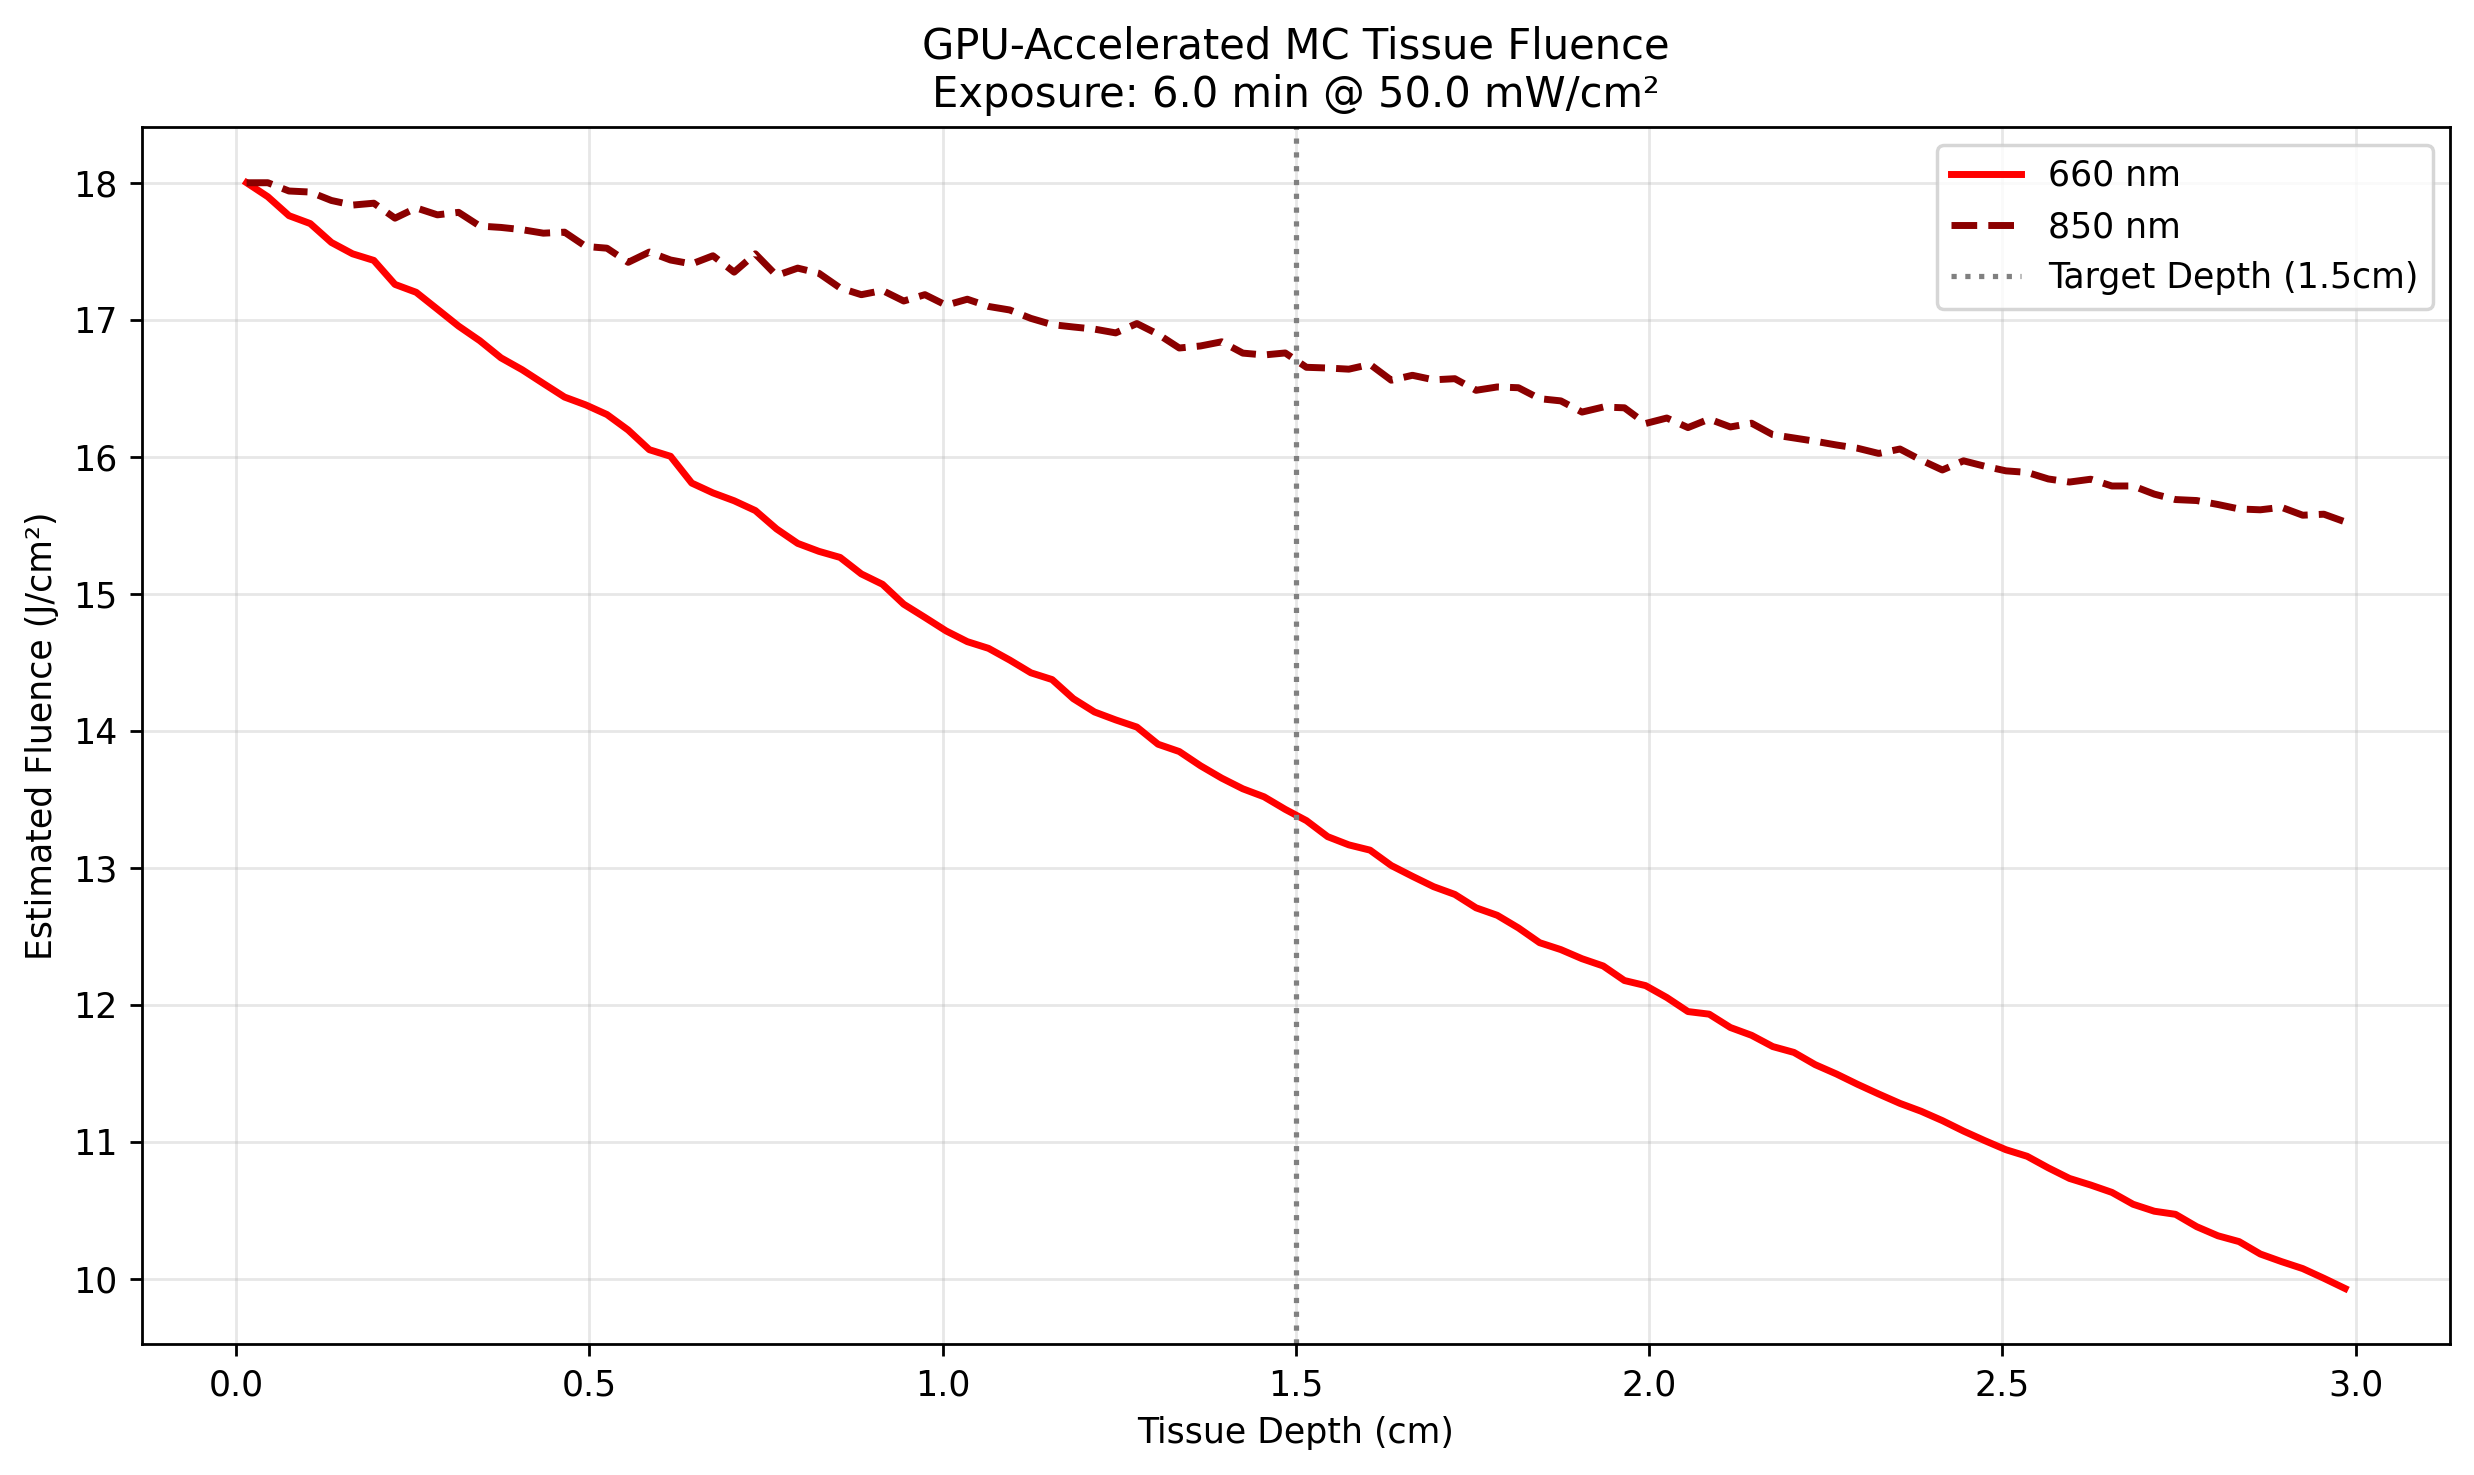

In [7]:
"""Simulates deep-tissue optical energy absorption using GPU-accelerated Monte Carlo.

This module leverages CuPy to perform parallel photon transport simulations,
allowing for significantly higher photon counts and better statistical
convergence than CPU-based implementations.
"""

import logging
from typing import Dict, Tuple, List

import matplotlib.pyplot as plt
import numpy as np

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ==========================================
# CONSTANTS (Control Knobs)
# ==========================================
DEVICE_POWER_WATTS = 15.0
ILLUMINATION_AREA_CM2 = 300.0
TARGET_EXPOSURE_MINUTES = 6.0
TISSUE_DEPTH_CM = 3.0
TARGET_MUSCLE_DEPTH_CM = 1.5
PHOTON_PACKETS = 1_000_000

OPTICAL_PROPERTIES = {
    660: {'mu_a': 0.20, 'mu_s_prime': 10.0},
    850: {'mu_a': 0.05, 'mu_s_prime': 8.0}
}

PLOT_PARAMS = {
    'figure.dpi': 250,
    'font.sans-serif': ['Tahoma', 'DejaVu Sans'],
    'font.weight': 'normal'
}

def check_gpu_health():
    """Verifies that CuPy can communicate with the L4 GPU.

    Returns:
        bool: True if GPU is functional, False otherwise.
    """
    try:
        import cupy as cp
        # Attempt a tiny allocation to trigger the driver handshake
        cp.array([1, 2, 3])
        logger.info(f"GPU Verified: {cp.cuda.Device(0).attributes['MultiProcessorCount']} SMs active.")
        return True
    except Exception as e:
        logger.error(f"GPU Driver Error: {e}")
        logger.error("Please restart the runtime and ensure you installed cupy-cuda12x.")
        return False

def calculate_surface_fluence() -> float:
    """Calculates the total energy delivered per unit area at the skin surface.

    Returns:
        The surface fluence in Joules per square centimeter (J/cm²).
    """
    irradiance_w_cm2 = DEVICE_POWER_WATTS / ILLUMINATION_AREA_CM2
    exposure_seconds = TARGET_EXPOSURE_MINUTES * 60.0
    return irradiance_w_cm2 * exposure_seconds

def simulate_photon_transport_gpu(
    wavelength: int,
    properties: Dict[str, float],
    depth_cm: float,
    packets: int,
    bins: int = 100
) -> Tuple[np.ndarray, np.ndarray]:
    """Executes a vectorized 1D random walk on the GPU.

    Args:
        wavelength: The wavelength of light in nm.
        properties: Dictionary containing 'mu_a' and 'mu_s_prime'.
        depth_cm: The maximum simulation depth in cm.
        packets: Number of photon packets to simulate.
        bins: Number of spatial bins for energy deposition.

    Returns:
        A tuple containing the bin center depths and the relative energy profile.
    """
    import cupy as cp

    mu_a = properties['mu_a']
    mu_s = properties['mu_s_prime']
    mu_t = mu_a + mu_s
    albedo = mu_s / mu_t

    # GPU Initialization
    z = cp.zeros(packets, dtype=cp.float32)
    weight = cp.ones(packets, dtype=cp.float32)
    active_mask = cp.ones(packets, dtype=cp.bool_)
    absorbed_energy_gpu = cp.zeros(bins, dtype=cp.float32)

    # Correct Binning Setup: Create N+1 edges to get N bins
    bin_edges = cp.linspace(0, depth_cm, bins + 1)

    while cp.any(active_mask):
        # Generate random steps for all photons at once
        steps = -cp.log(cp.random.random(packets, dtype=cp.float32)) / mu_t
        z += steps * active_mask

        deposited = weight * (1 - albedo) * active_mask

        # Vectorized histogram accumulation
        counts, _ = cp.histogram(z, bins=bin_edges, weights=deposited)
        absorbed_energy_gpu += counts.astype(cp.float32)

        weight -= deposited
        active_mask = (weight > 0.01) & (z < depth_cm)

    # --- Calculate Bin Centers ---
    # bin_edges is size (bins + 1).
    # We take the average of the left and right edge of each bin to get the center.
    edges_cpu = np.linspace(0, depth_cm, bins + 1)
    depth_bins = (edges_cpu[:-1] + edges_cpu[1:]) / 2

    energy_profile = cp.asnumpy(absorbed_energy_gpu)

    total_abs = np.sum(energy_profile)
    if total_abs > 0:
        energy_profile /= total_abs

    return depth_bins, energy_profile

def plot_dosimetry(results: List[Dict], surface_irradiance: float) -> None:
    """Generates a professional visualization of the simulation results."""
    plt.rcParams.update(PLOT_PARAMS)
    plt.figure(figsize=(10, 6))

    colors = {660: 'red', 850: 'darkred'}
    styles = {660: '-', 850: '--'}

    for res in results:
        plt.plot(
            res['depths'], res['fluence'],
            color=colors.get(res['wavelength'], 'blue'),
            linestyle=styles.get(res['wavelength'], '-'),
            label=res['label'], linewidth=2
        )

    plt.axvline(
        x=TARGET_MUSCLE_DEPTH_CM, color='gray', linestyle=':',
        label=f'Target Depth ({TARGET_MUSCLE_DEPTH_CM}cm)'
    )

    plt.title(
        f'GPU-Accelerated MC Tissue Fluence\n'
        f'Exposure: {TARGET_EXPOSURE_MINUTES} min @ {surface_irradiance*1000:.1f} mW/cm²'
    )
    plt.xlabel('Tissue Depth (cm)')
    plt.ylabel('Estimated Fluence (J/cm²)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def main() -> None:
    """Main execution pipeline for the GPU PBM simulation."""
    if not check_gpu_health():
        return

    logger.info(f"Starting GPU Simulation with {PHOTON_PACKETS} photons...")

    surface_fluence_j_cm2 = calculate_surface_fluence()
    surface_irradiance_w_cm2 = DEVICE_POWER_WATTS / ILLUMINATION_AREA_CM2

    simulation_results = []

    for wavelength, props in OPTICAL_PROPERTIES.items():
        logger.info(f"Processing wavelength: {wavelength}nm")

        depths, rel_energy = simulate_photon_transport_gpu(
            wavelength, props, TISSUE_DEPTH_CM, PHOTON_PACKETS
        )

        # Scale relative MC results to absolute surface fluence
        # Using max as a normalization point to preserve the shape of the MC decay
        abs_fluence = (rel_energy / np.max(rel_energy)) * surface_fluence_j_cm2

        mu_a, mu_s_p = props['mu_a'], props['mu_s_prime']
        eff_depth = 1 / np.sqrt(3 * mu_a * (mu_a + mu_s_p))
        logger.info(f"Wavelength {wavelength}nm: Effective Depth = {eff_depth:.3f} cm")

        simulation_results.append({
            'wavelength': wavelength,
            'depths': depths,
            'fluence': abs_fluence,
            'label': f'{wavelength} nm'
        })

    plot_dosimetry(simulation_results, surface_irradiance_w_cm2)
    logger.info("Simulation complete.")

if __name__ == "__main__":
    main()

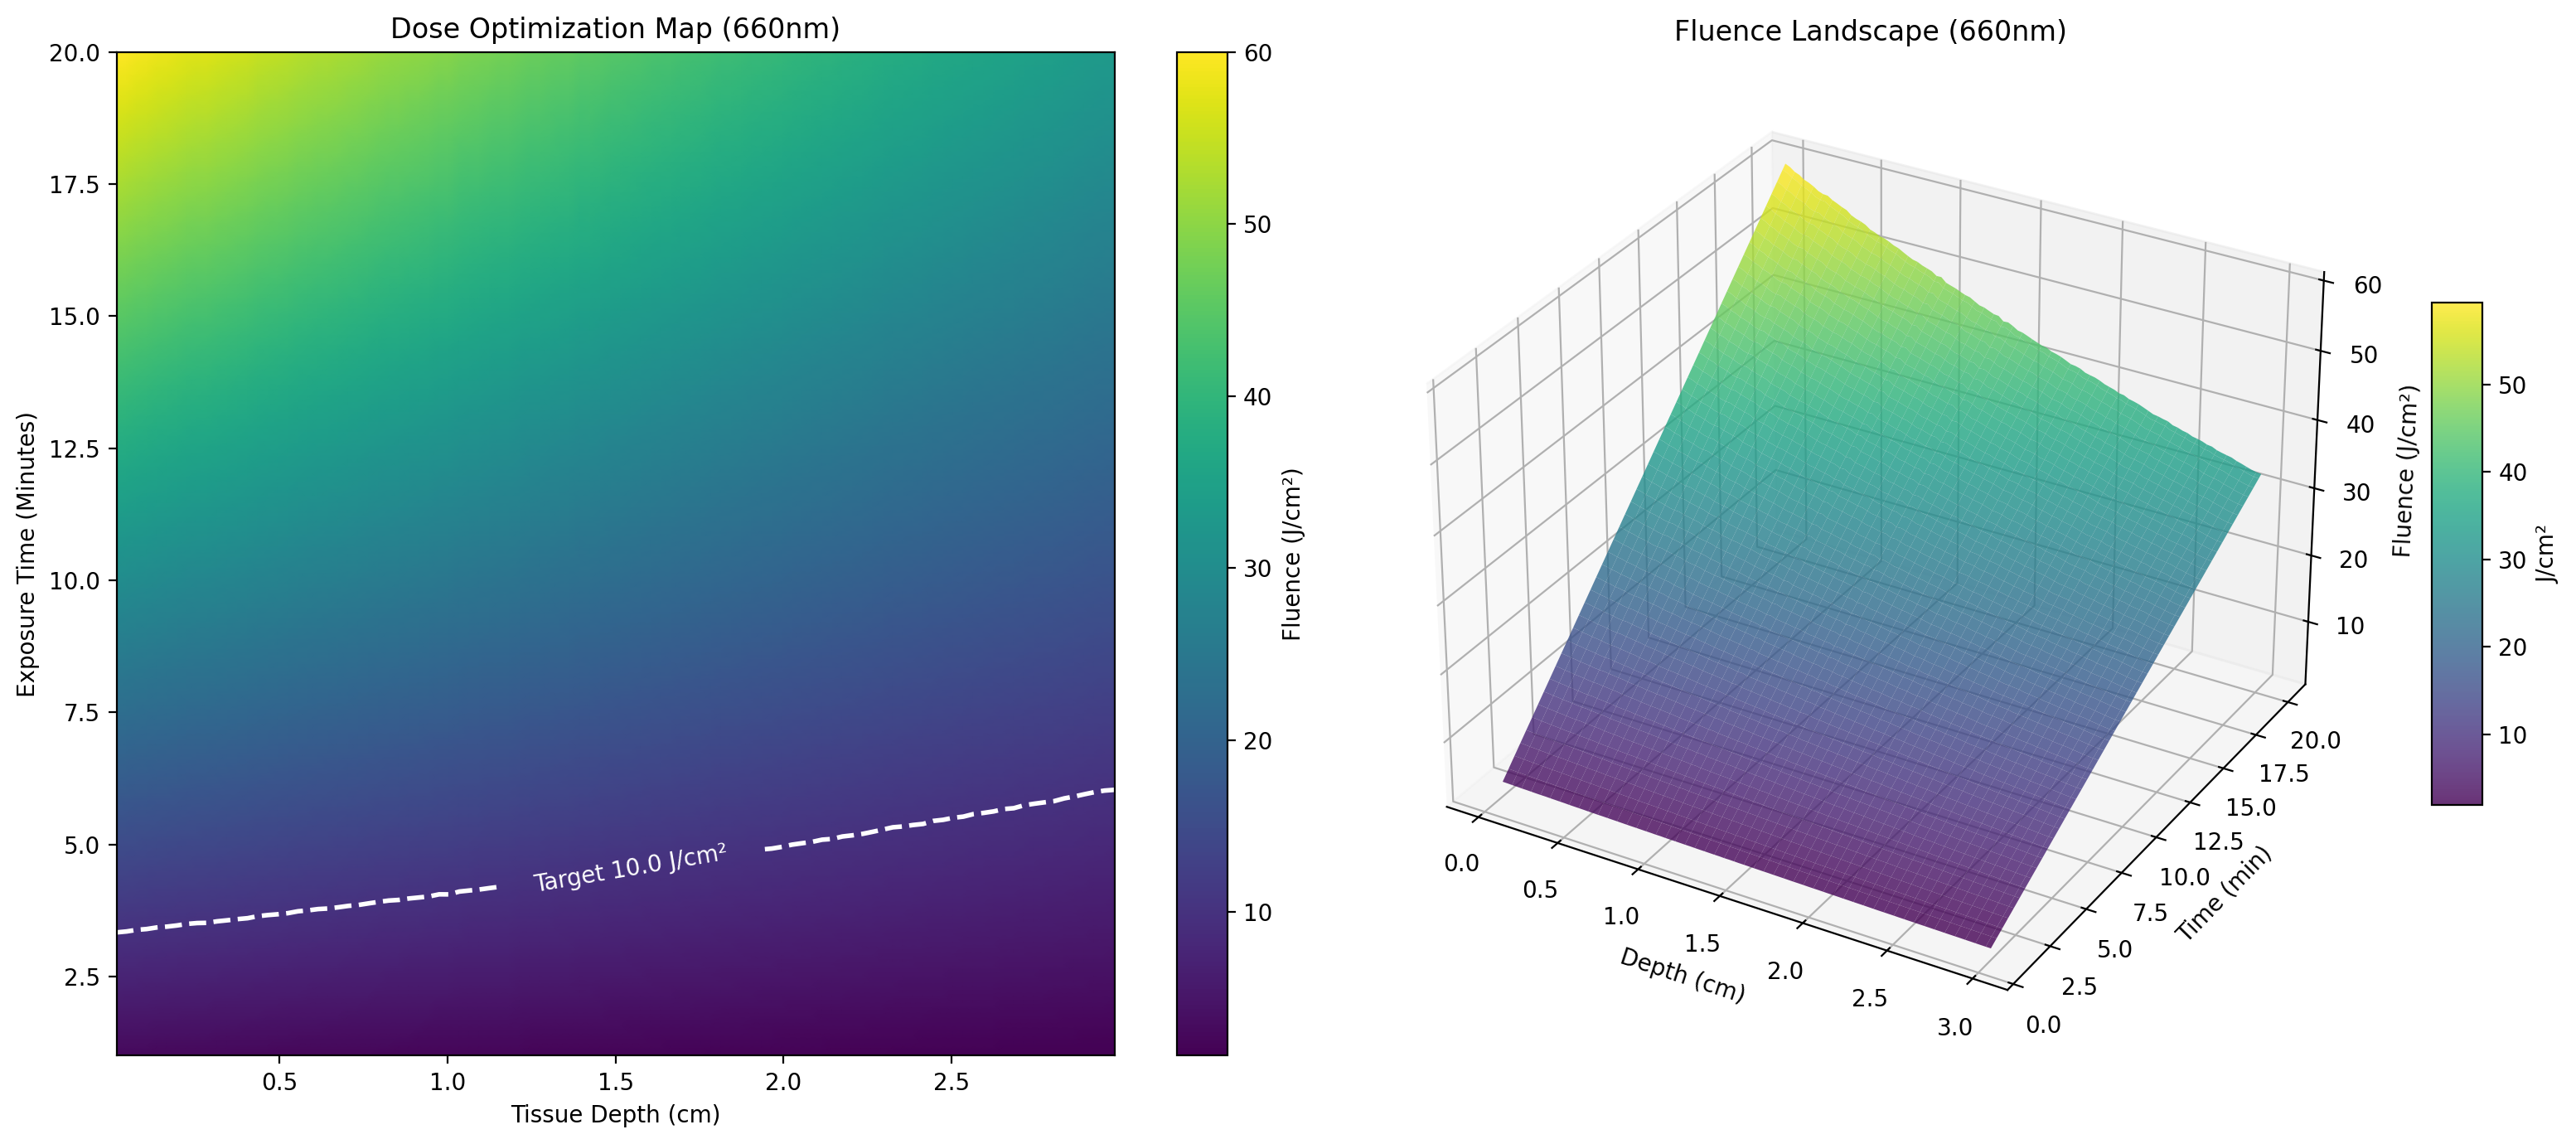

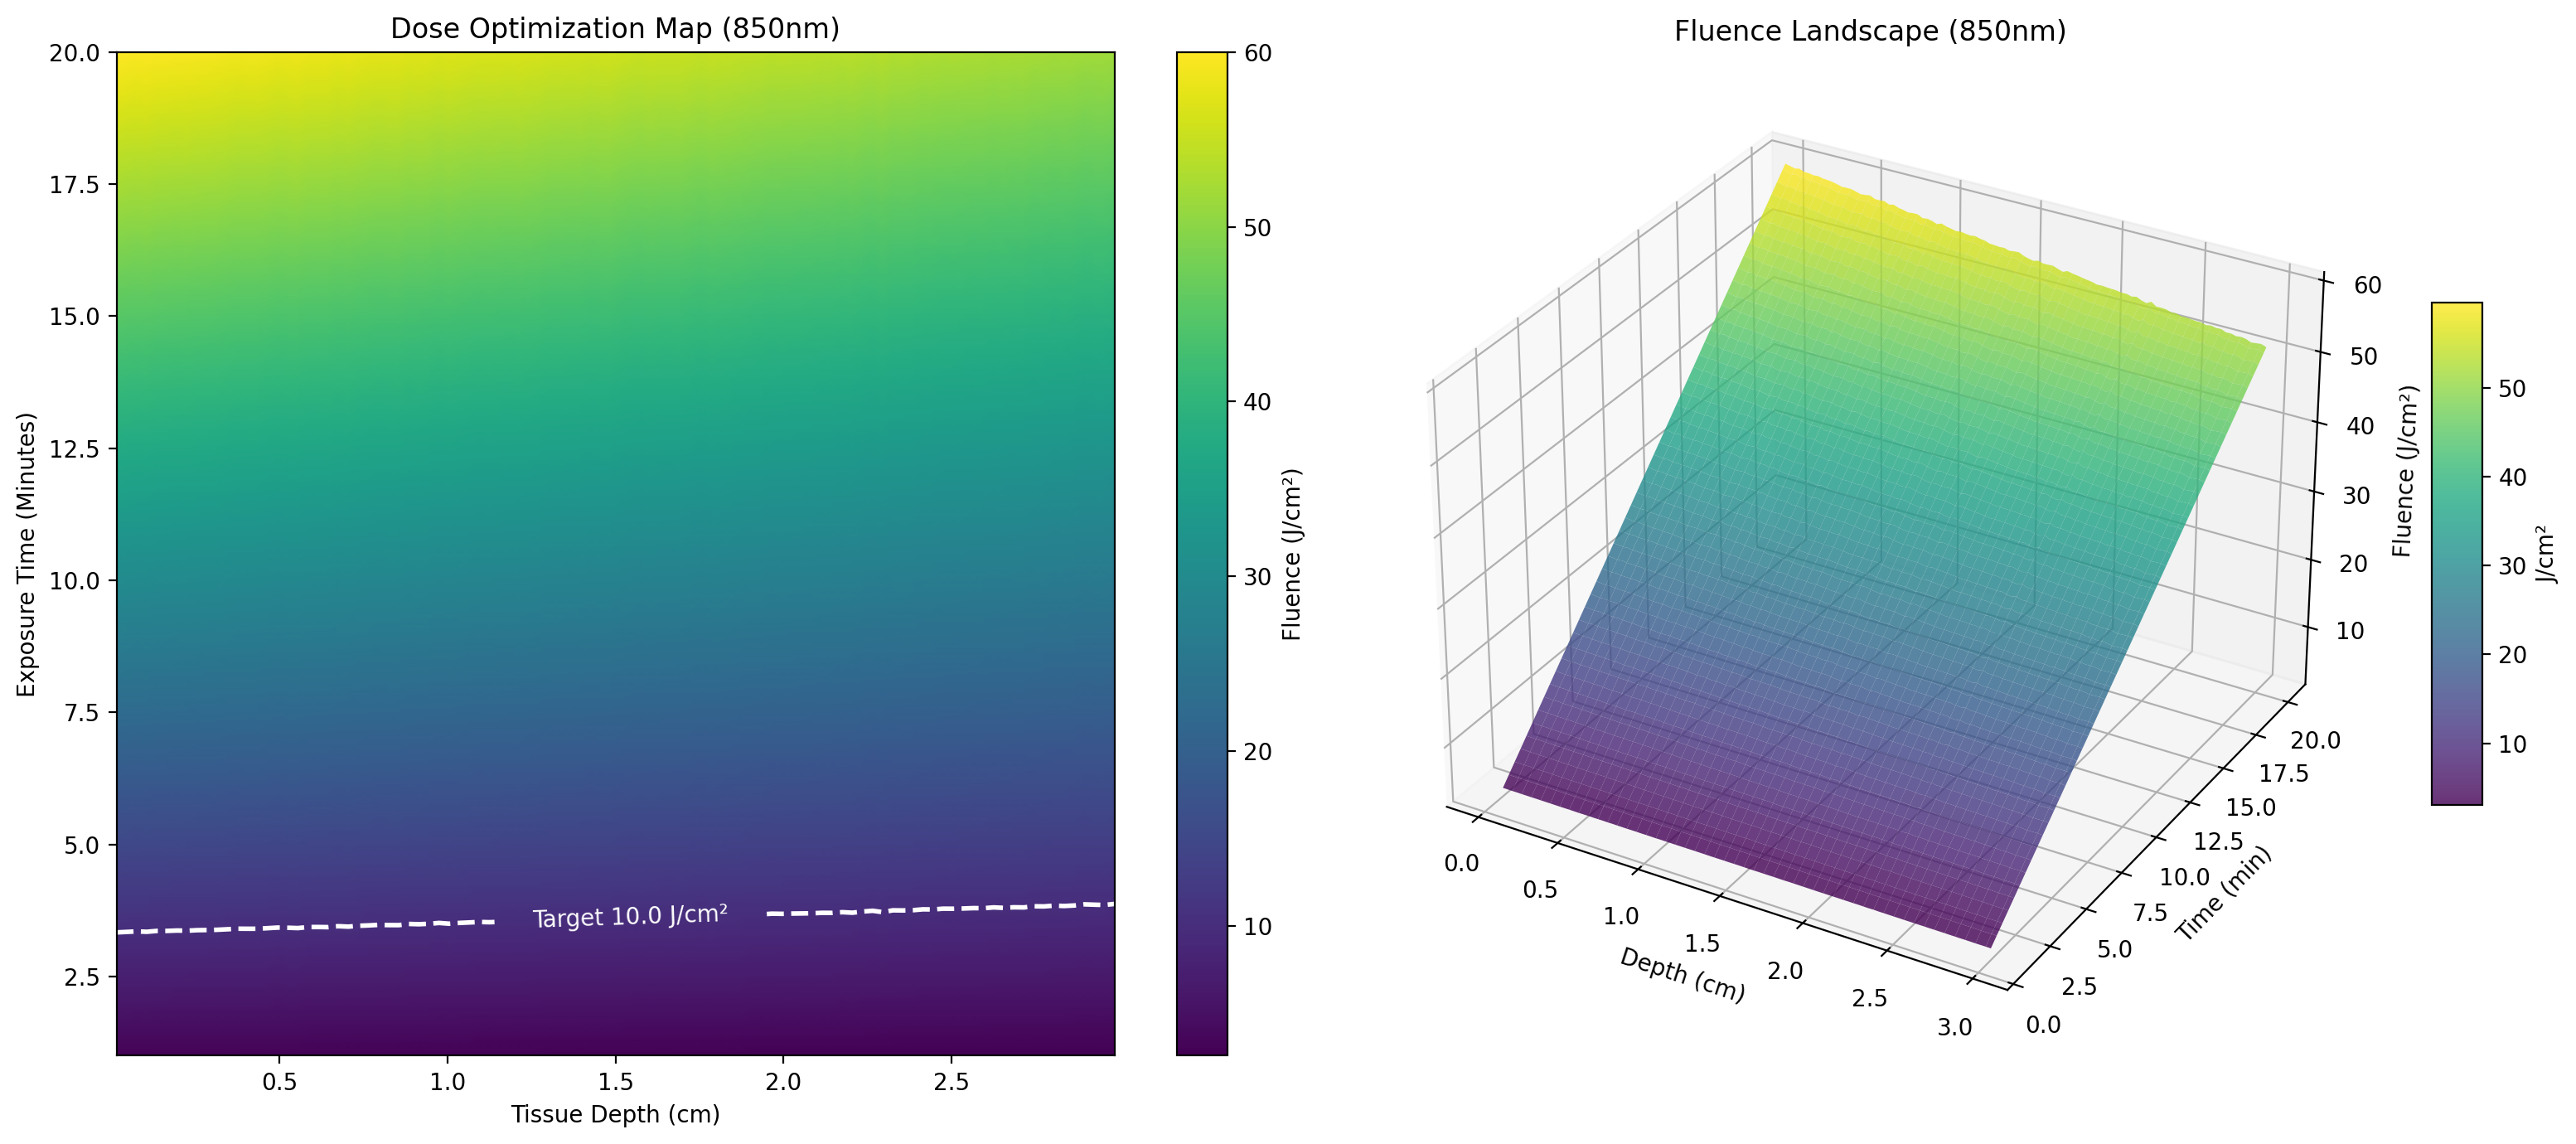

In [8]:
"""PBM Optical Dose Optimizer.

This module simulates photon transport using CuPy and generates optimization
maps to determine the required exposure time to reach a target therapeutic
fluence at various tissue depths.
"""

import logging
from typing import Dict, Tuple, List

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# ==========================================
# CONSTANTS (Control Knobs)
# ==========================================
DEVICE_POWER_WATTS = 15.0
ILLUMINATION_AREA_CM2 = 300.0
TISSUE_DEPTH_MAX_CM = 3.0
PHOTON_PACKETS = 1_000_000
TARGET_THERAPEUTIC_Dose_JCM2 = 10.0  # The "Goal" fluence for optimization

# Wavelength optical properties
OPTICAL_PROPERTIES = {
    660: {'mu_a': 0.20, 'mu_s_prime': 10.0},
    850: {'mu_a': 0.05, 'mu_s_prime': 8.0}
}

# Visualization Parameters
PLOT_PARAMS = {
    'figure.dpi': 200,
    'font.sans-serif': ['Tahoma', 'DejaVu Sans'],
}

class PBMAnalyzer:
    """Handles the simulation and analysis of PBM optical energy deposition."""

    def __init__(self, power: float, area: float):
        """Initializes the analyzer with device specifications.

        Args:
            power: Total optical power in Watts.
            area: Illumination area in cm².
        """
        self.power = power
        self.area = area
        self.surface_irradiance = power / area  # W/cm²

    def simulate_relative_distribution(
        self,
        wavelength: int,
        props: Dict[str, float],
        depth_cm: float,
        bins: int = 100
    ) -> Tuple[np.ndarray, np.ndarray]:
        """Runs a vectorized MC simulation to find the relative energy decay.

        Returns:
            A tuple of (depth_bins, relative_profile).
        """
        mu_a, mu_s = props['mu_a'], props['mu_s_prime']
        mu_t = mu_a + mu_s
        albedo = mu_s / mu_t

        z = cp.zeros(PHOTON_PACKETS, dtype=cp.float32)
        weight = cp.ones(PHOTON_PACKETS, dtype=cp.float32)
        active_mask = cp.ones(PHOTON_PACKETS, dtype=cp.bool_)
        absorbed_energy_gpu = cp.zeros(bins, dtype=cp.float32)
        bin_edges = cp.linspace(0, depth_cm, bins + 1)

        while cp.any(active_mask):
            steps = -cp.log(cp.random.random(PHOTON_PACKETS, dtype=cp.float32)) / mu_t
            z += steps * active_mask
            deposited = weight * (1 - albedo) * active_mask
            counts, _ = cp.histogram(z, bins=bin_edges, weights=deposited)
            absorbed_energy_gpu += counts.astype(cp.float32)
            weight -= deposited
            active_mask = (weight > 0.01) & (z < depth_cm)

        edges_cpu = np.linspace(0, depth_cm, bins + 1)
        depth_bins = (edges_cpu[:-1] + edges_cpu[1:]) / 2
        energy_profile = cp.asnumpy(absorbed_energy_gpu)

        # Normalize to a relative distribution (0 to 1)
        if np.sum(energy_profile) > 0:
            energy_profile /= np.max(energy_profile)

        return depth_bins, energy_profile

    def generate_dose_map(
        self,
        wavelength: int,
        time_range: np.ndarray,
        depth_bins: np.ndarray,
        rel_profile: np.ndarray
    ) -> np.ndarray:
        """Calculates a 2D map of Fluence vs Time and Depth.

        Args:
            wavelength: Wavelength of the light.
            time_range: Array of exposure times in minutes.
            depth_bins: Array of tissue depths in cm.
            rel_profile: The normalized MC distribution.

        Returns:
            A 2D NumPy array where [time_idx, depth_idx] is the fluence.
        """
        # Fluence = (Surface Irradiance * Time) * Relative Decay
        # time_range is in minutes, convert to seconds
        times_sec = time_range * 60.0

        # Using outer product to create the 2D grid: (Times, 1) * (1, Depths)
        surface_energy_grid = (self.surface_irradiance * times_sec)[:, np.newaxis]
        fluence_map = surface_energy_grid * rel_profile[np.newaxis, :]

        return fluence_map


def plot_optimization_results(
    wavelength: int,
    time_range: np.ndarray,
    depth_bins: np.ndarray,
    fluence_map: np.ndarray
) -> None:
    """Creates a heatmap and a 3D surface plot for dose optimization."""
    plt.rcParams.update(PLOT_PARAMS)
    fig = plt.figure(figsize=(16, 7))

    # 1. Heatmap (2D)
    ax1 = fig.add_subplot(121)
    im = ax1.pcolormesh(
        depth_bins, time_range, fluence_map,
        shading='gouraud', cmap='viridis'
    )
    plt.colorbar(im, label='Fluence (J/cm²)')

    # Add a contour line for the target therapeutic dose
    contour = ax1.contour(
        depth_bins, time_range, fluence_map,
        levels=[TARGET_THERAPEUTIC_Dose_JCM2],
        colors='white', linestyles='--', linewidths=2
    )

    ax1.clabel(contour, inline=True, fmt=f'Target {TARGET_THERAPEUTIC_Dose_JCM2} J/cm²', fontsize=10)
    ax1.set_title(f'Dose Optimization Map ({wavelength}nm)')
    ax1.set_xlabel('Tissue Depth (cm)')
    ax1.set_ylabel('Exposure Time (Minutes)')

    # 2. Surface Plot (3D)
    ax2 = fig.add_subplot(122, projection='3d')
    X, Y = np.meshgrid(depth_bins, time_range)
    surf = ax2.plot_surface(X, Y, fluence_map, cmap='viridis', edgecolor='none', alpha=0.8)

    ax2.set_title(f'Fluence Landscape ({wavelength}nm)')
    ax2.set_xlabel('Depth (cm)')
    ax2.set_ylabel('Time (min)')
    ax2.set_zlabel('Fluence (J/cm²)')
    fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=10, label='J/cm²')

    plt.tight_layout()
    plt.show()


def main() -> None:
    """Main orchestration pipeline."""
    # GPU Health Check
    try:
        import cupy as cp
        cp.array([1])
    except Exception as e:
        logger.error(f"GPU Error: {e}. Please restart runtime.")
        return

    analyzer = PBMAnalyzer(DEVICE_POWER_WATTS, ILLUMINATION_AREA_CM2)

    # Define the range for optimization (X and Y axes)
    time_range = np.linspace(1, 20, 100)      # 1 to 20 minutes

    for wavelength, props in OPTICAL_PROPERTIES.items():
        logger.info(f"Analyzing optimization for {wavelength}nm...")

        # 1. Get the relative photon distribution from GPU
        depth_bins, rel_profile = analyzer.simulate_relative_distribution(
            wavelength, props, TISSUE_DEPTH_MAX_CM
        )

        # 2. Generate the 2D Dose Map
        fluence_map = analyzer.generate_dose_map(
            wavelength, time_range, depth_bins, rel_profile
        )

        # 3. Visualize
        plot_optimization_results(wavelength, time_range, depth_bins, fluence_map)

    logger.info("Optimization analysis complete.")


if __name__ == "__main__":
    main()